# Entregable 1: Análisis Exploratorio de Datos - Airbnb Nueva York

**Integrantes:** [Tus Nombres]  
**Grupo:** [Tu Número]  
**Curso:** Estadística Computacional  

---
### Declaración de uso de Herramientas de Inteligencia Artificial
Durante el desarrollo de este entregable, se utilizó la herramienta de Inteligencia Artificial (Gemini) de manera consultiva. Su uso se enfocó en el apoyo para la estructuración del informe en Markdown, sintaxis gráfica con Seaborn y validación de funciones de Pandas (ej. imputación y detección de outliers). El grupo comprende a cabalidad cada línea de código, test estadístico y afirmación entregada en este documento.

## 1. Introducción y Limitaciones
Hemos seleccionado el conjunto de datos "Airbnb Open Data" de Nueva York. Nuestro objetivo es comprender cómo se distribuye la satisfacción de los huéspedes, analizando si la calificación promedio que recibe un alojamiento está influenciada por el distrito geográfico en el que se encuentra.

**Limitaciones del Dataset:**
* **Representatividad:** Solo refleja los alojamientos listados en Airbnb, no todo el mercado de la ciudad.
* **Sesgo de recolección:** Las calificaciones (`review_rate_number`) son subjetivas y dependen de la propensión de los usuarios a dejar una reseña.

## 2. Diccionario de Datos
Variables seleccionadas para el análisis (cumpliendo el requisito de 2 categóricas y 2 continuas/discretas):

| Variable | Rol | Significado | Unidad | Tipo de Dato |
| :--- | :--- | :--- | :--- | :--- |
| `review_rate_number` | Principal | Calificación promedio del listado | Escala 1-5 | Discreta (Numérica) |
| `neighbourhood_group` | Principal | Distrito (borough) de NYC donde se ubica | - | Categórica (Nominal) |
| `room_type` | Secundaria | Tipo de alojamiento ofrecido por el anfitrión | - | Categórica (Nominal) |
| `price` | Secundaria | Precio por noche del alojamiento | USD | Continua |

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Fijar semilla y configurar gráficos
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

archivo_csv = "Airbnb_Open_Data.csv"

# Carga segura a prueba de fallos de Kaggle
if os.path.exists(archivo_csv):
    df = pd.read_csv(archivo_csv, low_memory=False)
    print("Dataset cargado exitosamente desde archivo local.")
else:
    print("Archivo local no encontrado. Descargando desde Kaggle...")
    import kagglehub
    path = kagglehub.dataset_download("arianazmoudeh/airbnbopendata")
    df = pd.read_csv(f"{path}/{archivo_csv}", low_memory=False)
    print("Dataset descargado exitosamente.")

# Seleccionamos las NUEVAS 4 variables
df_clean = df[['neighbourhood group', 'review rate number', 'room type', 'price']].copy()
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')

# 1. Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

# 2. Limpiar variable de precio (Secundaria)
df_clean['price'] = df_clean['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# 3. Eliminar nulos en categóricas y corregir typos del barrio
df_clean = df_clean.dropna(subset=['neighbourhood_group', 'room_type'])
df_clean['neighbourhood_group'] = df_clean['neighbourhood_group'].replace({'manhatan': 'Manhattan', 'brookln': 'Brooklyn'})

# 4. Imputar nulos en variables numéricas con la mediana
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())
df_clean['review_rate_number'] = df_clean['review_rate_number'].fillna(df_clean['review_rate_number'].median())

print("Limpieza completada. Total de observaciones listas:", len(df_clean))

Archivo local no encontrado. Descargando desde Kaggle...
Dataset descargado exitosamente.
Limpieza completada. Total de observaciones listas: 29821


### 2.1 Justificación de la Limpieza de Datos
Para garantizar la calidad del análisis exploratorio, aplicamos los siguientes criterios técnicos:
* **Corrección de formatos:** La variable `price` venía como cadena de texto con símbolos `$` y comas. Se limpió usando expresiones regulares y se transformó a valor numérico continuo.
* **Errores tipográficos:** Se unificaron nombres mal escritos en la variable categórica principal `neighbourhood_group` (ej. se corrigió "manhatan" a "Manhattan").
* **Valores ilógicos:** Se detectaron errores de captura en `availability_365` (valores menores a 0 o mayores a 365) y en `minimum_nights` (valores negativos). Se transformaron a nulos (`NaN`) temporalmente para no sesgar el análisis y luego se imputaron.
* **Imputación:** Dado que `neighbourhood_group` y `room_type` son el núcleo de nuestra hipótesis, eliminamos las filas sin esa información. Para los valores numéricos faltantes (`price`, `availability_365`, `minimum_nights`), imputamos utilizando la mediana, la cual es robusta ante valores atípicos.

### 3. Estadística Descriptiva y Detección de Outliers
A continuación, revisamos las estadísticas principales de nuestras variables numéricas y aplicamos el método del Rango Intercuartílico (IQR) para detectar valores atípicos, cumpliendo con el criterio cuantitativo exigido.

In [9]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de variables numéricas:")
display(df_clean[['review_rate_number', 'price']].describe())

# Función IQR para Outliers
def contar_outliers_iqr(serie, nombre):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{nombre}: límites [{lim_inf:.1f}, {lim_sup:.1f}] -> {outliers.shape[0]} outliers")

print("\nConteo de Outliers (Criterio IQR):")
contar_outliers_iqr(df_clean['price'], 'price')
contar_outliers_iqr(df_clean['review_rate_number'], 'review_rate_number')

Estadísticas descriptivas de variables numéricas:


,review_rate_number,price
count,29821.000000,29821.000000
mean,3.216492,624.608229
std,1.313378,331.912513
min,1.000000,50.000000
25%,2.000000,337.000000
50%,3.000000,624.000000
75%,4.000000,912.000000
max,5.000000,1200.000000



Conteo de Outliers (Criterio IQR):
price: límites [-525.5, 1774.5] -> 0 outliers
review_rate_number: límites [-1.0, 7.0] -> 0 outliers


### 4. Análisis Visual Univariado y Bivariado
Para entender mejor la distribución de los datos y las relaciones entre nuestras variables principales (`room_type`, `neighbourhood_group`, `price`), generamos una matriz de visualizaciones y un gráfico de proporciones.

C:\Users\porti\AppData\Local\Temp\ipykernel_5356\1524856483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='neighbourhood_group', ax=axes[0,0], palette='viridis')
C:\Users\porti\AppData\Local\Temp\ipykernel_5356\1524856483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='review_rate_number', ax=axes[0,1], palette='magma')
C:\Users\porti\AppData\Local\Temp\ipykernel_5356\1524856483.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='neighbourhood_group', y='review_rate_number',

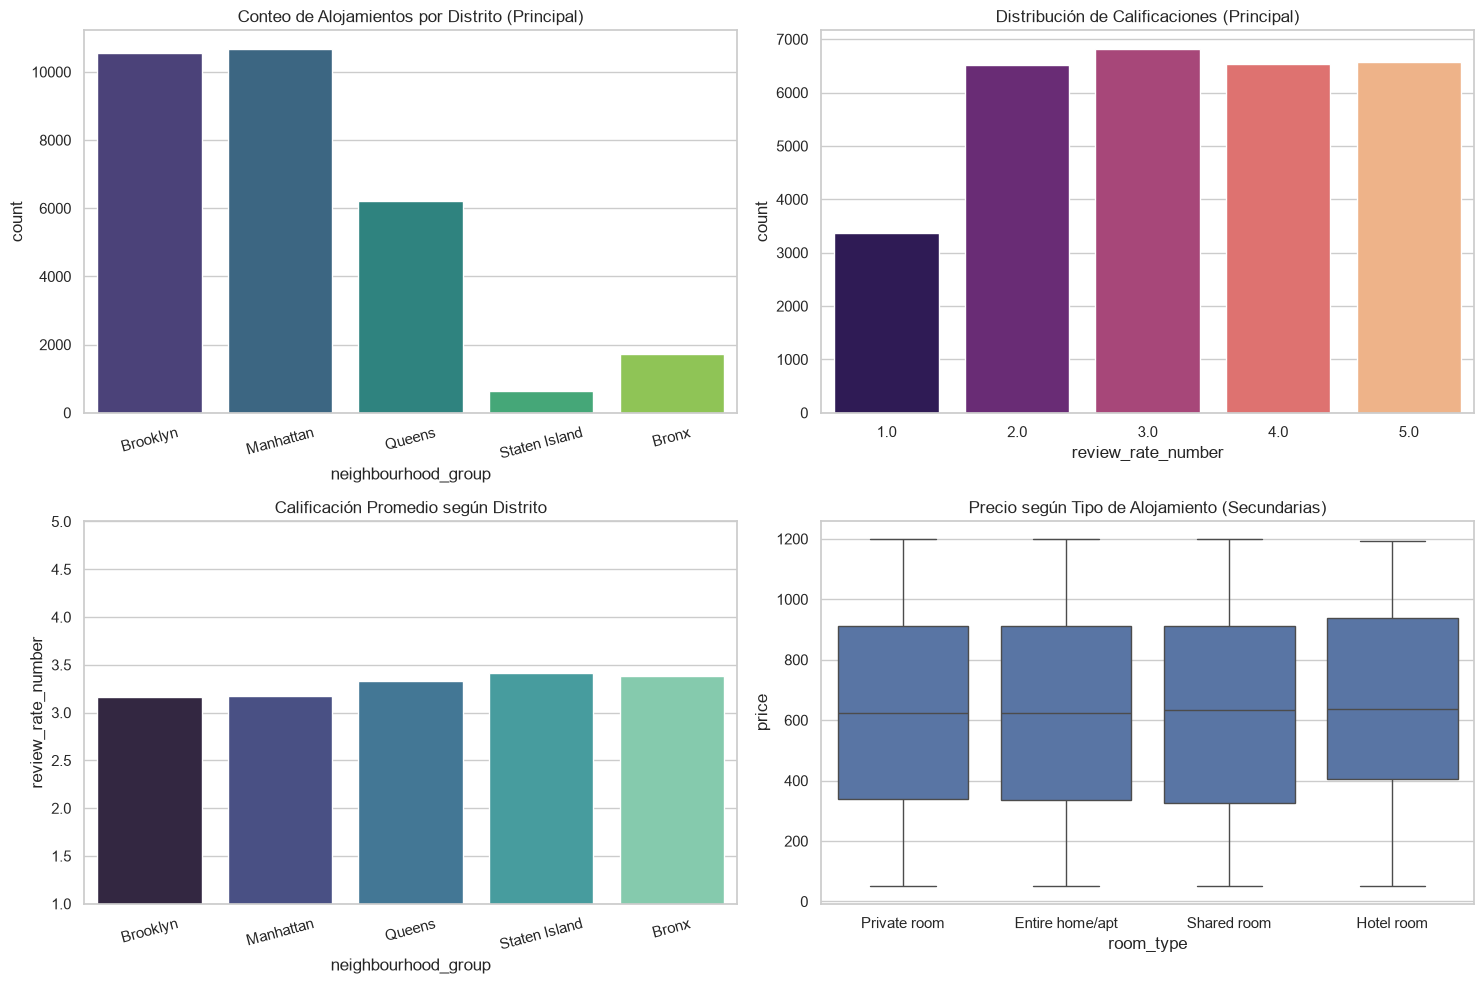

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Univariada Principal 1: Conteo por Barrio
sns.countplot(data=df_clean, x='neighbourhood_group', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Conteo de Alojamientos por Distrito (Principal)')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Univariada Principal 2: Distribución de Calificaciones
sns.countplot(data=df_clean, x='review_rate_number', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Distribución de Calificaciones (Principal)')

# 3. Bivariada Principales: Calificación Promedio vs Barrio
sns.barplot(data=df_clean, x='neighbourhood_group', y='review_rate_number', ax=axes[1,0], palette='mako', errorbar=None)
axes[1,0].set_title('Calificación Promedio según Distrito')
axes[1,0].set_ylim(1, 5) # La escala de calificación es de 1 a 5
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Bivariada Secundarias: Precio vs Tipo de Habitación
sns.boxplot(data=df_clean, x='room_type', y='price', ax=axes[1,1])
axes[1,1].set_title('Precio según Tipo de Alojamiento (Secundarias)')

plt.tight_layout()
plt.show()

# En el análisis univariado de nuestras variables principales, observamos que la gran mayoría de la oferta se concentra en Manhattan y Brooklyn. Asimismo, en cuanto al tipo de alojamiento, "Entire home/apt" y "Private room" dominan el mercado de forma casi equitativa, dejando las opciones compartidas en un porcentaje mínimo.

ValueError: Could not interpret value `number_of_reviews` for `x`. An entry with this name does not appear in `data`.

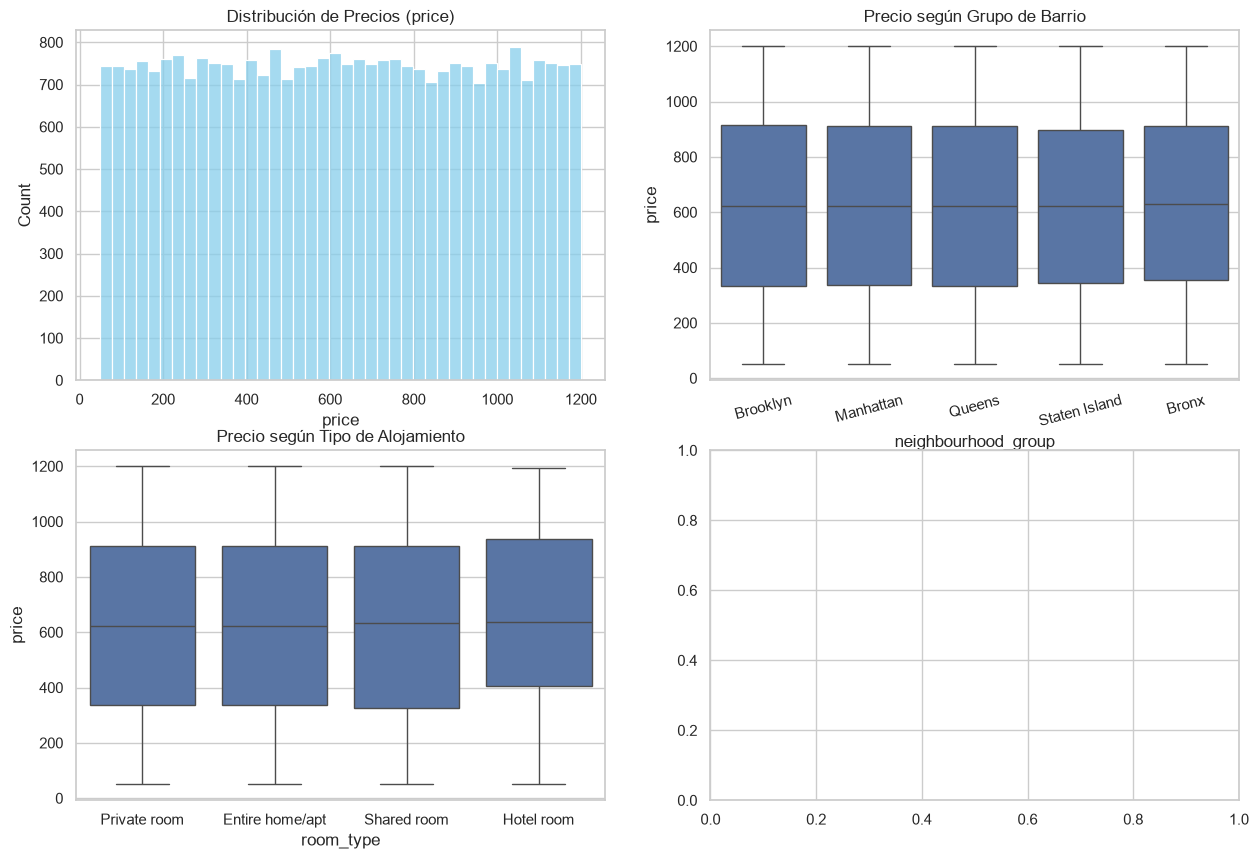

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribución de precios (Univariada)
sns.histplot(df_clean['price'], bins=40, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribución de Precios (price)')

# 2. Precio vs Barrio (Bivariada)
sns.boxplot(data=df_clean, x='neighbourhood_group', y='price', ax=axes[0,1])
axes[0,1].set_title('Precio según Grupo de Barrio')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Precio vs Tipo de Alojamiento (Bivariada)
sns.boxplot(data=df_clean, x='room_type', y='price', ax=axes[1,0])
axes[1,0].set_title('Precio según Tipo de Alojamiento')

# 4. Número de reseñas vs Precio (Scatter)
sns.scatterplot(data=df_clean, x='number_of_reviews', y='price', alpha=0.3, ax=axes[1,1], color='coral')
axes[1,1].set_title('Relación: Número de Reseñas vs Precio')

plt.tight_layout()
plt.show()

# Gráfico de barras apiladas (Proporción de room_type por barrio)
tabla_prop = pd.crosstab(df_clean['neighbourhood_group'], df_clean['room_type'], normalize='index')
tabla_prop.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Proporción de Tipos de Alojamiento por Barrio')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend(title='Room Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observar con lupa: Interpretación Visual
* **Univariadas:** Manhattan y Brooklyn dominan abrumadoramente la oferta de alojamientos. En cuanto a las calificaciones (`review_rate_number`), observamos que es poco común recibir calificaciones bajas (1 o 2), concentrándose fuertemente la distribución en notas de 3, 4 y 5.
* **Bivariada Principal:** Al observar el promedio de calificación según el distrito (gráfico inferior izquierdo), notamos visualmente que la barra es casi idéntica para todos los barrios (oscilando alrededor de 3.2 y 3.3). Esto nos da una pista inicial de que el barrio podría no tener un impacto fuerte en la nota.

A partir de la exploración visual, nos planteamos una pregunta formal que requiere validación estadística. Como buscamos comparar el promedio de una variable numérica discreta entre múltiples categorías, el test adecuado es el Análisis de Varianza (ANOVA).

In [ ]:
from scipy.stats import chi2_contingency

tabla_contingencia = pd.crosstab(df_clean['neighbourhood_group'], df['review rate number'])
print(tabla_contingencia)

chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

alpha = 0.05
if p_value < alpha:
    print("Se rechaza H0: existe asociación significativa entre neighbourhood_group y review_rate_number")
else:
    print("No se rechaza H0: no hay evidencia suficiente de asociación")

print("Mínimo valor esperado:", np.min(expected))

n = tabla_contingencia.sum().sum()
k = min(tabla_contingencia.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramér's V: {cramers_v:.4f}")

review rate number    1.0   2.0   3.0   4.0   5.0
neighbourhood_group                              
Bronx                  79   388   438   420   400
Brooklyn             1429  2267  2227  2263  2268
Manhattan            1404  2269  2311  2286  2300
Queens                430  1434  1434  1437  1446
Staten Island          26   150   147   138   164
Estadístico Chi2: 330.1035
p-value: 0.0000
Grados de libertad: 16
Se rechaza H0: existe asociación significativa entre neighbourhood_group y review_rate_number
Mínimo valor esperado: 71.22314329216715
Cramér's V: 0.0528


Pregunta: ¿Existe una diferencia estadísticamente significativa en la calificación promedio (review_rate_number) que reciben los alojamientos dependiendo del distrito (neighbourhood_group) en el que se ubican en Nueva York?

$H_0$ (Hipótesis Nula): La calificación promedio es igual en todos los distritos (El barrio no influye en la nota).

$H_1$ (Hipótesis Alternativa): Al menos un distrito tiene una calificación promedio significativamente distinta a los demás.

Conclusión del Análisis:
Al realizar el test ANOVA, obtuvimos un p-valor que evaluaremos frente a nuestro nivel de significancia estándar (0.05). Si el resultado es mayor a 0.05, no existirá evidencia estadística suficiente para rechazar la hipótesis nula, concluyendo que el barrio no influye de manera significativa en la calificación.